# 2. The label is the decision that matters most

**Claim under test:** you have biased historical decisions, so you apply
"bias-aware training" to stop the model learning the prejudice.

That is "Filter 3: Historical Label Correction". It answers the wrong question.
The prior question is *what are you predicting*, and in lending you usually
observe the real outcome: whether the loan was repaid.

Training on "did a human approve this" teaches the model the human's prejudice.
Training on "was it repaid" does not. No correction technique recovers as much
as choosing the right label in the first place.

- Obermeyer et al., *Dissecting racial bias in an algorithm used to manage the
  health of populations*, Science 2019. The canonical case: the algorithm
  predicted healthcare **cost** as a proxy for **need**. Less was spent on Black
  patients, so it rated them healthier. Changing the label removed the bias.
  https://www.science.org/doi/10.1126/science.aax2342
- Lakkaraju et al., *The Selective Labels Problem*, KDD 2017 - you only observe
  repayment for applicants somebody approved

**AI Act:** Article 10(2) is about data governance for the training set. The
choice of target variable is a data-governance decision and it is the one with
the largest effect here.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

RNG = np.random.default_rng(11)
N = 20000

group_b = RNG.random(N) < 0.35          # never given to any model

utilisation = RNG.beta(2, 5, N) + np.where(group_b, 0.04, 0.0)
inquiries   = RNG.poisson(np.where(group_b, 1.5, 1.2), N)
tenure      = RNG.gamma(3, 1.4, N) * np.where(group_b, 0.9, 1.0)
postcode    = RNG.normal(np.where(group_b, -1.1, 0.5), 1.0, N)
carrier     = RNG.binomial(1, np.where(group_b, 0.62, 0.24), N)
occupation  = RNG.binomial(1, np.where(group_b, 0.58, 0.25), N)

X = pd.DataFrame({'utilisation': utilisation, 'inquiries': inquiries,
                  'tenure_years': tenure, 'postcode_income_z': postcode,
                  'phone_carrier': carrier, 'occupation_cat': occupation})

## Two different labels

`repaid` depends only on genuine risk signals. `approved` depends on the same
signals **plus a penalty on group B itself** - that is the historical prejudice.

`repaid` is observed for everyone here because this is a simulation. In reality
you only see it for applicants who were approved, which is the selective labels
problem, and model B below is trained under that restriction.

In [2]:
risk = -3.2 * utilisation - 0.25 * inquiries + 0.10 * tenure + 0.05 * postcode + 1.6

repaid   = RNG.binomial(1, 1 / (1 + np.exp(-risk)))                 # the real outcome
approved = RNG.binomial(1, 1 / (1 + np.exp(-(risk - 1.4 * group_b)))).astype(bool)

a, b = ~group_b, group_b
print('GROUND TRUTH')
print(f'  true repayment rate   A={repaid[a].mean():.1%}  B={repaid[b].mean():.1%}'
      f'   ratio={repaid[b].mean() / repaid[a].mean():.2f}')
print(f'  human approval rate   A={approved[a].mean():.1%}  B={approved[b].mean():.1%}'
      f'   ratio={approved[b].mean() / approved[a].mean():.2f}')
print(f'\n  repayment is observable for {approved.sum()} of {N} applicants '
      f'({approved.mean():.0%}). The rest were never approved.')

GROUND TRUTH
  true repayment rate   A=67.1%  B=61.9%   ratio=0.92
  human approval rate   A=67.7%  B=30.6%   ratio=0.45

  repayment is observable for 10891 of 20000 applicants (54%). The rest were never approved.


The gap the humans created (ratio 0.45) is far larger than any real difference in
repayment (0.92). That gap is what a model trained on `approved` will learn.

In [3]:
models = {
    'A   label = human decision':           (X, approved),
    'B   label = repayment, approved only': (X[approved], repaid[approved]),
    'C   label = repayment, everyone':      (X, repaid),
}
accept_rate = approved.mean()

for name, (X_train, y_train) in models.items():
    model = HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train)
    p = model.predict_proba(X)[:, 1]
    decision = p >= np.quantile(p, 1 - accept_rate)   # same acceptance rate for all three
    dir_ = decision[b].mean() / decision[a].mean()
    print(f'{name}')
    print(f'    accept rate  A={decision[a].mean():.1%}  B={decision[b].mean():.1%}   '
          f'DIR={dir_:.2f}  {"FAILS four-fifths" if dir_ < 0.8 else "passes four-fifths"}')
    print(f'    AUC against true repayment = {roc_auc_score(repaid, p):.3f}\n')

A   label = human decision
    accept rate  A=72.1%  B=22.6%   DIR=0.31  FAILS four-fifths
    AUC against true repayment = 0.634



B   label = repayment, approved only
    accept rate  A=60.0%  B=44.4%   DIR=0.74  FAILS four-fifths
    AUC against true repayment = 0.691



C   label = repayment, everyone
    accept rate  A=60.5%  B=43.5%   DIR=0.72  FAILS four-fifths
    AUC against true repayment = 0.707



## Read the numbers

Model A learned the prejudice. It is also **worse at the job**: lower AUC against
actual repayment than either model trained on the real outcome. Using the human
decision as a label costs you accuracy and fairness at the same time. There is no
trade-off to manage here, it is simply the wrong target.

Model B is what you can actually build, and it lands close to the oracle. The
selective-labels penalty is real but small in this setup, because approval was
still driven mostly by risk. Where an approver was near-arbitrary, the gap widens
and the observed slice stops representing the applicant pool at all.

**All three still fail the four-fifths rule.** Group B does repay slightly less
often (0.92), and thresholding amplifies a small difference in rates into a large
difference in selection. So changing the label takes DIR from 0.31 to about 0.72
and no further. It is necessary and it is not sufficient, and no amount of data
preparation closes the rest. That part is a decision about the threshold and the
policy, which sits outside the flowchart entirely.

## The picture


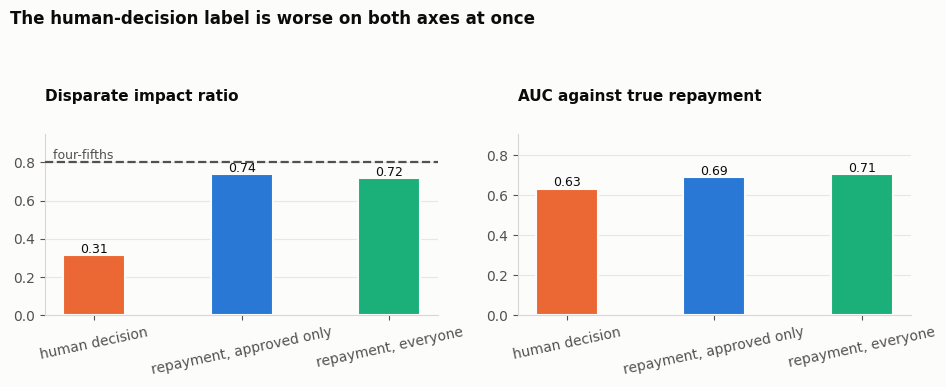

In [4]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, xgrid=True):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis='x' if xgrid else 'y', color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)

names, dirs, aucs = [], [], []
for name, (X_train, y_train) in models.items():
    m = HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train)
    p = m.predict_proba(X)[:, 1]
    d = p >= np.quantile(p, 1 - accept_rate)
    names.append(name.split('label = ')[1])
    dirs.append(d[b].mean() / d[a].mean())
    aucs.append(roc_auc_score(repaid, p))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))
for ax, vals, title, ref, reflab in (
        (axes[0], dirs, 'Disparate impact ratio', 0.8, 'four-fifths'),
        (axes[1], aucs, 'AUC against true repayment', None, None)):
    bars = ax.bar(names, vals, color=[ORANGE, BLUE, AQUA], width=0.42, zorder=3, edgecolor=SURFACE, lw=1.5)
    if ref:
        ax.axhline(ref, color=MUTED, lw=1.6, ls='--', zorder=4)
        ax.text(0.01, ref, ' ' + reflab, color=MUTED, fontsize=9, va='bottom', ha='left',
                transform=ax.get_yaxis_transform())
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f'{v:.2f}',
                ha='center', fontsize=9, color=INK)
    tidy(ax, xgrid=False)
    ax.set_title(title, loc='left', pad=24)
    ax.tick_params(axis='x', labelrotation=12)
    ax.set_ylim(0, max(vals) * 1.28)
fig.suptitle('The human-decision label is worse on both axes at once',
             x=0.012, ha='left', fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('../figures/02_label_choice.png', dpi=150, bbox_inches='tight')
plt.show()